# Graphene: From Ground State to Excitations
**by <span style="color:darkgreen">Pasquale Pavone</span>, <span style="color:darkgreen">Caterina Cocchi</span>, <span style="color:darkgreen">Wahib Aggoune</span>, & <span style="color:darkgreen">Ronaldo Rodrigues Pela</span> for [<span style="color:darkgoldenrod">exciting *sodium*</span>](https://www.exciting-code.org/sodium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Tejus Rohatgi</span>, <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**:  In this tutorial you will learn how to set up and execute <code><b>exciting</b></code> calculations for graphene. Examples of electronic band-structure calculations and full structure optimization will be also shown. Finally, the loss function is presented as an example for the calculation of excited-states properties.

<div class="alert alert-block alert-warning">
    
**Table of Contents**

[0. Before Starting](#0)
    
[1. Basic background on graphene](#1)

[2. Using exciting for calculating properties of graphene](#2)
    
* [Two dimensional structures are treated as special three-dimensional periodic systems](#2-1) 
* [Preparation of the input file](#2-2)
* [Execute calculations](#2-3)
* [Density of states](#2-4)
* [Electronic band-structure](#2-5)
    
[3. Full structure optimization](#3)
  
[4. Convergence tests](#4)

[5. Is graphene really planar?](#5)

[6. Excited-states properties: The loss function](#6)

* [Converging the loss spectrum w.r.t. the mesh in reciprocal space](#6-1) 
* [Converging the loss spectrum w.r.t. the number of basis functions](#6-2)
    
</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

Here is a list of the scripts which are relevant for this tutorial with a short description.

* <code><b>setup.elastic_strain.py</b></code>: Python script for generating strained structures.
* <code><b>setup.planar.py</b></code>: Python script for setting calculations for two-dimensional materials.
* <code><b>setup.graphene_along_c.py</b></code>: Python script for generating graphene structures in which an atom is displaced along the c axis.
* <code><b>execute.single.py</b></code>: Python script for running a single <code><b>exciting</b></code> calculation.
* <code><b>execute.elastic_strain.py</b></code>: Python script for running a series of <code><b>exciting</b></code> calculations.
* <code><b>execute.diamond_phonon_g.py</b></code>: Python script for running a series of <code><b>exciting</b></code> calculations.
* <code><b>plot.birch.py</b></code>: Python script for fitting energy-vs-volume curves using <b>BM-EoS</b>.
* <code><b>plot.files.py</b></code>: Python visualization tool for multiple files with the same name in different directories (for more details, see [<span style="color:firebrick;font-weight:bold">The python script "plot.files.py"</span>](https://exciting-code.org/home/about/the-python-script-plot.files).
* <code><b>plot.optimized_geometry.py</b></code>: Python visualization tool for relaxed coordinates of atoms in the unit cell.
* <code><b>plot.band_structure.py</b></code>: Python visualization script for plotting and comparing energy bands(for more details, see [<span style="color:firebrick;font-weight:bold">The python script "plot.band_structure.py"</span>](https://exciting-code.org/home/about/the-python-script-plot.band_structure).
* <code><b>plot.dos.py</b></code>: Python visualization script for plotting and comparing density of states (for more details, see [<span style="color:firebrick;font-weight:bold">The python script "plot.dos.py"</span>](https://exciting-code.org/home/about/the-python-script-plot.dos).

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Basic background on graphene</span>

Graphene is a two-dimensional material composed by carbon atoms in a hexagonal structure (honeycomb lattice), as shown in the left panel of the following figure.

<figure>
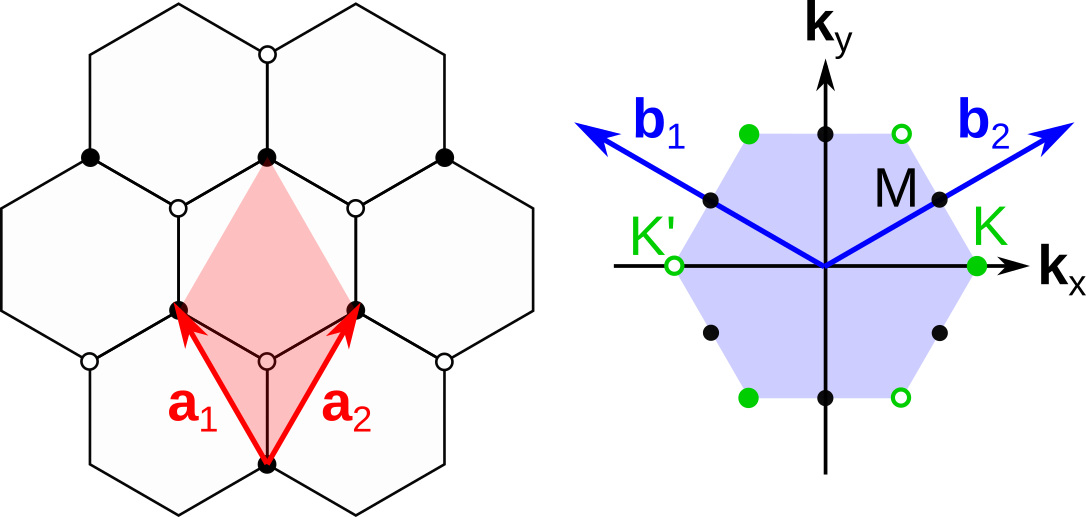
</figure>

This structure can be described as a hexagonal lattice with a basis of two atoms. One choice for the lattice vectors is

<a id='e1'></a>
\begin{equation}
\tag{1}
\mathbf{a}_{1} = a \left(-\frac{1}{2},\frac{\sqrt{3}}{2}\right)   \quad\text{and}\quad 
\mathbf{a}_{2}= a \left(\frac{1}{2},\frac{\sqrt{3}}{2}\right)
\end{equation}

where $a = 2.46\ Å$ is the experimental lattice constant. The reciprocal-lattice vectors are:

<a id='e2'></a>
\begin{equation}
\tag{2}
\mathbf{b}_{1} = \frac{2\pi}{a} \left(-1,\frac{\sqrt{3}}{3}\right)   \quad\text{and}\quad 
\mathbf{b}_{2}= \frac{2\pi}{a} \left(1,\frac{\sqrt{3}}{3}\right)
\end{equation}

Of particular importance for the physics of graphene are the <b>K</b> points at the corners of the first Brillouin zone. These are named Dirac points due to the particular feature of the electronic band structure, illustrated in the next figure with a three-dimensional plot of the uppermost occupied (blue) and the lowermost empty (red) bands.

<figure>
    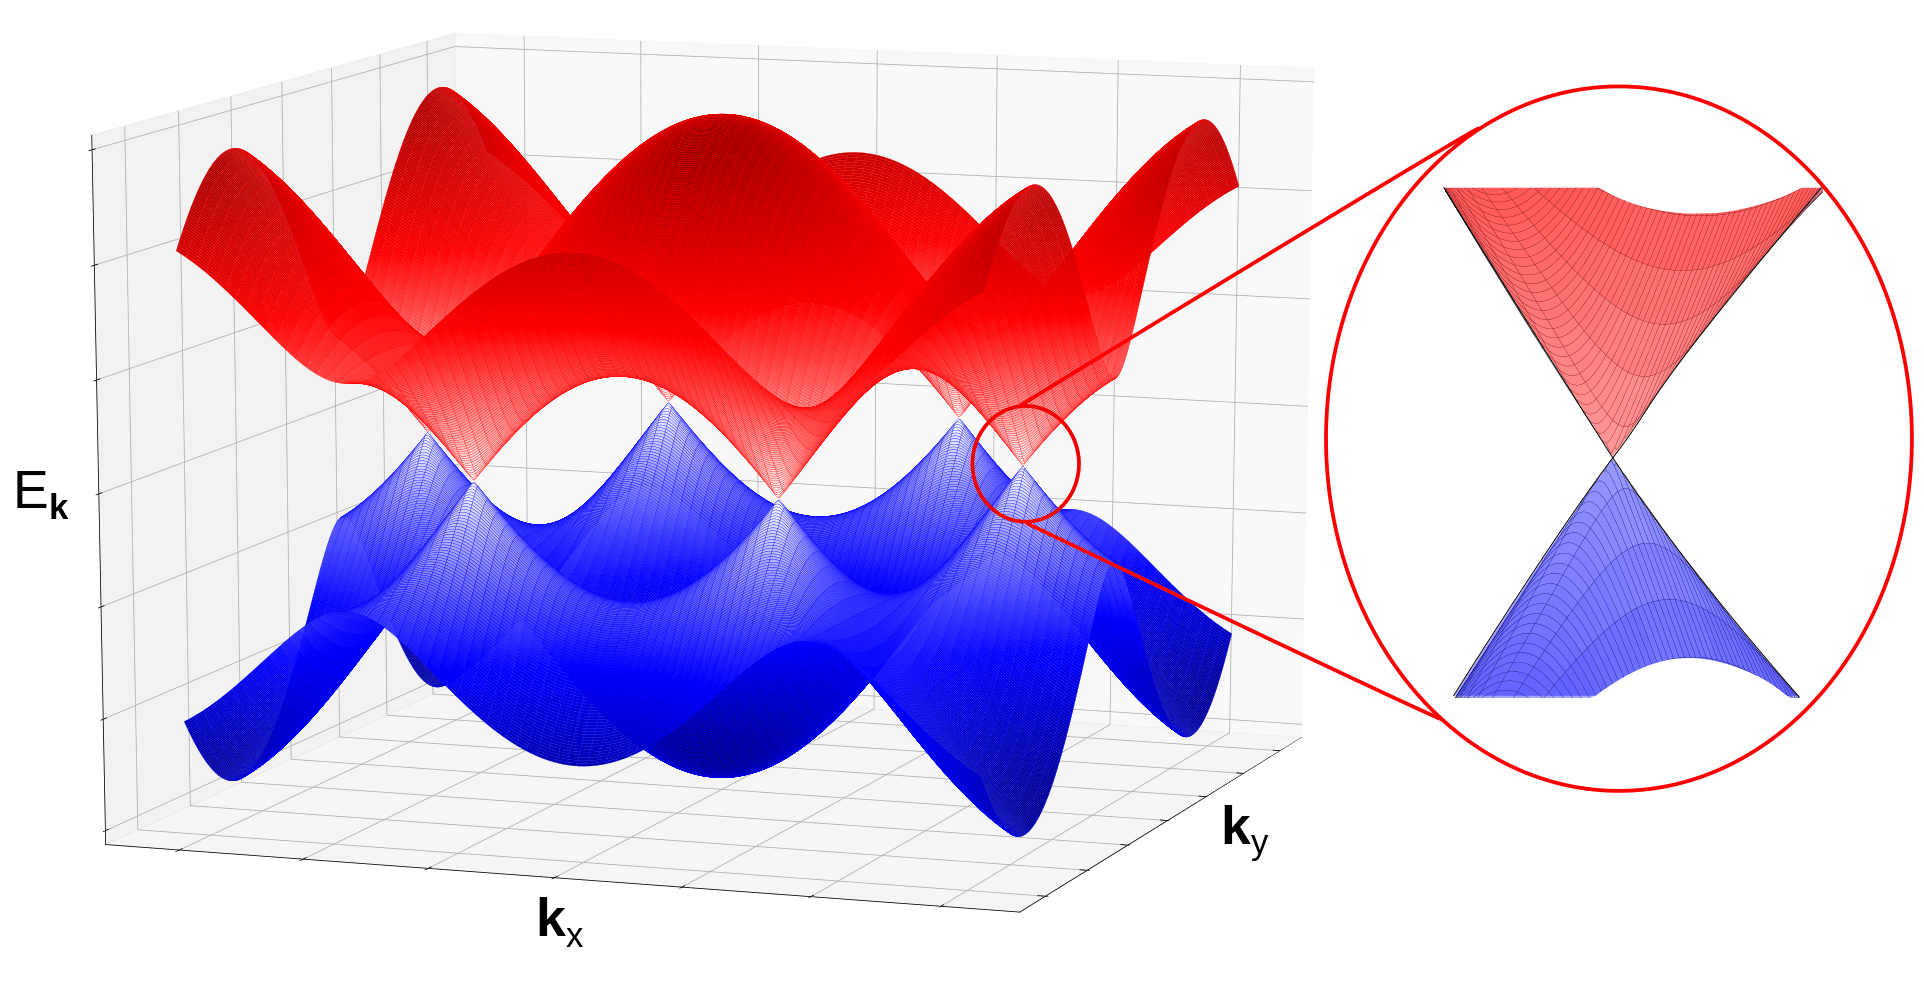
</figure>
    

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Using exciting for calculating properties of graphene</span>

<a id='2-1'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>2.1 Two dimensional structures are treated as *special* three-dimensional periodic systems</b>

Since <code><b>exciting</b></code> assumes three-dimensional periodicity along the directions defined by the lattice vectors, to simulate the two-dimensional system, some care needs to be taken. The solution is to consider a <i>special</i> three-dimensional crystal where the distances between a monolayer and its <i>replica</i> are <b>large enough</b> so that each monolayer behaves as it would be isolated. This is illustrated in the next figure.

<figure>
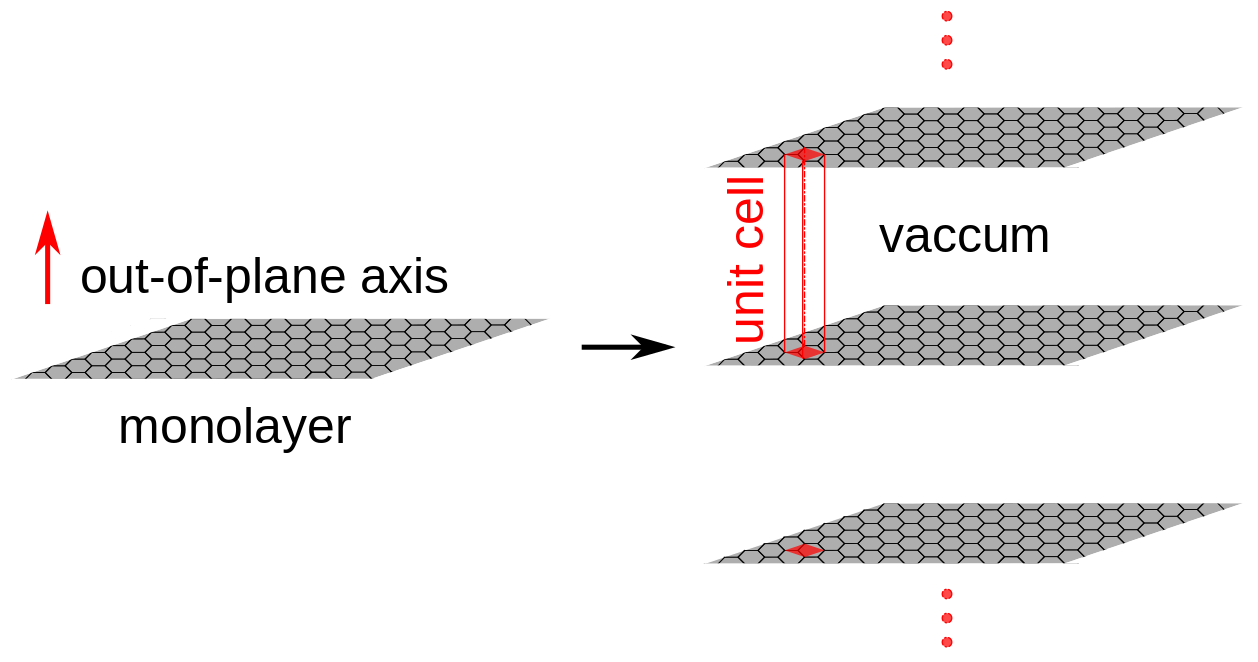
</figure>

As seen, a three-dimensional structure is created by replicating the monolayer along the out-of-plane axis at a given interlayer distance, corresponding to the amount of "vacuum" added to the system. Its size has to be selected to prevent interlayer interactions.

<a id='2-2'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>2.2 Preparation of the input file</b>

Initially, create a directory for this tutorial, <span style="font-weight:bold">graphene</span>.

In [1]:
%%bash
mkdir -p graphene

The input file (<b>input.xml</b>) for graphene is given in the following.

<span class="GRAPHENE_INPUT"></span>
```xml
<input>
 
   <title>Graphene</title>
 
   <structure speciespath="$EXCITINGROOT/species">
 
      <crystal scale="4.65">
         <basevect> -0.5  0.8660254040  0.0 </basevect>
         <basevect>  0.5  0.8660254040  0.0 </basevect>
         <basevect>  0.0  0.0000000000  6.0 </basevect>
      </crystal>
      <species speciesfile="C.xml" rmt="1.20">
         <atom coord="0.00000000  0.00000000  0.0"/>
         <atom coord="0.33333333  0.33333333  0.0"/>
      </species>
 
   </structure>
 
   <groundstate
      do="fromscratch"
      xctype="GGA_PBE"
      ngridk="8 8 1"
      rgkmax="4"
      swidth="0.01">
   </groundstate>
 
</input>
```

In [2]:
from excitingjupyter.utilities import get_input_xml_from_notebook

input_str = get_input_xml_from_notebook("graphene_from_ground_state_to_excitations", "GRAPHENE_INPUT")

# Write out the input as an XML file:
with open('./graphene/input.xml', "w") as fid:
    fid.write(input_str)

<hr style="border:1px solid #DDD"> </hr>

<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Understanding the entries in input.xml</span></strong> 
    
</summary>  
    
Input files for <code><b>exciting</b></code> are written in the <b>XML</b> format and are typically named <b>input.<b>xml</b></b>. The <b>XML</b> format allows your data to be written in a structured way. Figuratively speaking, an <code><b>exciting</b></code> input is pretty much like an article with its sections and subsections. In case of <b>XML</b> data, sections and subsections are called <span style="color:mediumblue;font-weight:bold">elements</span>.

Let us examine this example bit-by-bit. The first thing to be said is that an <b>XML</b> is <span style="color:red;font-weight:bold">not sensitive</span> to line indentation. However, for the sake of clarity, line indentation is used in all examples of this tutorial to illustrate the hierarchy among elements. Now, let's come back to the <b>input.xml</b> shown above. The first and the last line indicate the beginning and the end of the input.

The element <code><span style="color:green;font-weight:bold">title</span></code> contains some freely chosen text simply to describe the calculation. Keywords <code><span style="color:green;font-weight:bold">&lttitle&gt</span></code> and <code><span style="color:green;font-weight:bold">&lt/title&gt</span></code> indicate the beginning and the end of the element (note in the second keyword the presence and position of the slash <code><span style="color:green;font-weight:bold">/</span></code>

The next element, <code><span style="color:green;font-weight:bold">structure</span></code>, describes the geometry and the chemical composition of a studied system. Note that the declaration of the <code><span style="color:green;font-weight:bold">structure</span></code> section contains as additional information the parameter <code><span style="color:mediumblue;font-weight:bold">speciespath</span></code>.

```xml
    <structure speciespath="$EXCITINGROOT/species/">
```

Such parameters in the <b>XML</b> language are called <code><span style="color:mediumblue;font-weight:bold">attributes</span></code>, and their values are always given in quotes regardless of whether it is numerical, symbolic, or boolean information. In particular, the attribute <code><span style="color:mediumblue;font-weight:bold">speciespath</span></code> defines the location, where the files with the data about chemical elements are stored.

<span style="color:red;font-weight:bold">Please, note that exciting is always using atomic units (Hartree, Bohr, etc.)!</span> Thus, you can notice that in the example above the value of the experimental lattice constant of graphene has been considered (in units of bohr!).

```xml
...
      <crystal scale="4.65">
...
```

Let us now investigate in more detail the other instructions given in the input file. The lattice vectors are chosen according to Eq. [(1)](e1):

```xml
...
         <basevect> -0.5  0.8660254040  0.0 </basevect>
         <basevect>  0.5  0.8660254040  0.0 </basevect>
         <basevect>  0.0  0.0000000000  6.0 </basevect>
...
```

Note also that the amount of "vacuum" along the out-of-plane direction is set to 6 times the value of the in-plane lattice constant (<code><span style="color:mediumblue;font-weight:bold">scale</span></code> = <b>"4.65"</b>).

The position of the two atoms of carbon inside the unit cell of graphene is chosen according to the first figure of this tutorial.

```xml
...
      <species speciesfile="C.xml" rmt="1.20">
         <atom coord="0.00000000  0.00000000  0.0"/>
         <atom coord="0.33333333  0.33333333  0.0"/>
      </species>
...
```

In the last part of the input file, there is a list of the parameters which are set for this calculation:

```xml
...
   <groundstate
      do="fromscratch"
      xctype="GGA_PBE"
      ngridk="8 8 1"
      rgkmax="4"
      swidth="0.01">
   </groundstate>
...
```

In particular:

* The <b>GGA_PBE</b> functional is chosen for the exchange-correlation energy.
* Brillouin-zone integration are performed by summing contributions from a <b>8</b>$\times$<b>8</b>$\times$<b>1</b> <b>k</b>-points grid. Notice that, due to the fact that one assumes that no interaction is present between the monolayer and its periodic replicas, the number of <b>k</b>-points along the out-of-plane direction is set to <span style="color:brown;font-weight:bold">1</span>.
* The number of <b>LAPW</b> basis functions used in the calculation is set by assigning a value to the attribute <code><span style="color:mediumblue;font-weight:bold">rgkmax</span></code>.
* A Gaussian smearing width of <span style="color:brown;font-weight:bold">0.01 Ha</span> is chosen for including the zero-gap metallic effects on the <b>k</b>-points grid.
</details>

<a id='2-3'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>2.3 Execute calculations</b>

To perform the first calculation for graphene, create the <b>input.xml</b> (as provided above) inside the current directory (<b>graphene/</b>).

<span style="color:red;font-weight:bold">N.B.</span>: Do not forget to replace in the <b>input.xml</b> the string "<b><span>&#36;</span>EXCITINGROOT</b>" by the actual value of the environment variable <code><span style="color:mediumblue">$EXCITINGROOT</span></code> using the command

In [3]:
%%bash
cd graphene
python3 -m excitingscripts.setup.excitingroot
cd ..

For the first calculations, create a subdirectory **test_1** and copy the input file there. You can now run the script <code><b>execute.single.py</b></code> in the current directory (where <b>input.xml</b> is).

In [4]:
%%bash
cd graphene
mkdir -p test-1
cp ./input.xml test-1
python3 -m excitingscripts.execute.single -r test-1
cd ..

This calculation solves self-consistently the Kohn-Sham equations and allows us to determine the ground-state total energy. For more information, check the file <b>test-1/INFO.OUT</b>.

<a id='2-4'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>2.4 Density of states</b>

After the ground-state is completed, it is time to investigate more properties. One of the most fundamental ones is the density of states (<b>DOS</b>): it provides information on how many electronic states there are at a given energy. To calculate it, move inside the directory <b>test-1</b>. Then, modify the file <b>input.xml</b> inside this directory (for more details, see [<strong><span style="color:firebrick">Input Reference</span></strong>](https://exciting-code.org/home/about/input-reference)) as described below:

1. in the element <code><span style="color:green">groundstate</span></code>, change the attribute <code><span style="color:mediumblue">do</span></code>do to <b>"skip"</b>;
2. add the element <code><span style="color:green">properties</span></code> after <code><span style="color:green">groundstate</span></code>;
3. insert the sub-element <code><span style="color:green">dos</span></code> into the element <code><span style="color:green">properties</span></code>;
4. add the attribute <code><span style="color:mediumblue">nsmdos</span></code> = <b>"3"</b> to the element <code><span style="color:green">dos</span></code>.

The <b>input.xml</b> file should look like this:

```xml
...
   <groundstate
      do="skip"
      ...
   </groundstate>
 
   <properties>
 
      <dos nsmdos="3"/>
 
   </properties>
...
```

In [5]:
# The following lines modify the input.xml using Python
from excitingtools import ExcitingInputXML, ExcitingGroundStateInput, ExcitingPropertiesInput

parsed_input = ExcitingInputXML.from_xml("./graphene/test-1/input.xml")

groundstate = {'do': 'skip',
  'xctype': 'GGA_PBE',
  'ngridk': [8, 8, 1],
  'rgkmax': 4,
  'swidth': 0.01}

properties= {'dos': {'nsmdos': 3}}

parsed_input.groundstate = ExcitingGroundStateInput(**groundstate)
parsed_input.properties = ExcitingPropertiesInput(**properties)

parsed_input.write("./graphene/test-1/input.xml")

Now, execute <code><b>exciting</b></code> with:

In [6]:
%%bash
cd graphene/test-1
python3 -m excitingscripts.execute.single
cd ../../

This should take only a few seconds. Then, to visualize the <b>DOS</b>, execute

In [7]:
%%bash
cd graphene/test-1
python3 -m excitingscripts.plot.dos
cd ../../

The script <code><b>plot.dos.py</b></code> (discussed in details in [<span style="color:firebrick;font-weight:bold">The python script "plot.dos.py"</span>](https://exciting-code.org/home/about/the-python-script-plot.dos)) produces the <b>PNG</b> file <b>PLOT.png</b>. You can visualize this file with standard tools.

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Questions</b></span>

* Does the <b>DOS</b> reveal the presence of a gap? Why?
* What would you expect due to the existence of the Dirac cones?
* Is the <b>K</b> point included in the <code><span style="color:mediumblue">ngridk</span></code> mesh?
* What does it change if you use <code><span style="color:mediumblue">ngridk</span></code> = <b>"9 9 1"</b>? Why?
* How does the value of the density of states at the Fermi energy change if the <b>k</b> is made finer (still containing the <b>K</b> point)?
</div>

<a id='2-5'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>2.5 Electronic band-structure</b>

The electronic band-structure details the dependence of the energy eigenvalues on the wavevectors <b>k</b>. To obtain it, proceed as follows:

* Comment or delete the sub-element <code><span style="color:green">dos</span></code> inside <code><span style="color:green">properties</span></code>.

```xml
      <!--dos nsmdos="3"/-->
```
* Insert the sub-element <code><span style="color:green">bandstructure</span></code> inside <code><span style="color:green">properties</span></code> with the following specifications:

```xml
...
   <properties>
      ...
      <bandstructure>
         <plot1d>
            <path steps="1000">
               <point coord="0.0           0.0          0.0" label="GAMMA"/>
               <point coord="0.33333333   -0.33333333   0.0" label="K"    />
               <point coord="0.5          -0.5          0.0" label="M"    />
               <point coord="1.0           0.0          0.0" label="GAMMA"/> 
            </path>
         </plot1d>
      </bandstructure>
 
   </properties>
...
```

Now execute <code><b>exciting</b></code> with the command:

In [8]:
# The following lines modify the input.xml using Python
parsed_input = ExcitingInputXML.from_xml("./graphene/test-1/input.xml")

properties= {'bandstructure': {'plot1d': {'path': {'steps': 1000,
     'point': [{'coord': [0.0, 0.0, 0.0], 'label': 'GAMMA'},
      {'coord': [0.33333333, -0.33333333, 0.0], 'label': 'K'},
      {'coord': [0.5, -0.5, 0.0], 'label': 'M'},
      {'coord': [0.0, 0.0, 0.0], 'label': 'GAMMA'}]}}}}

parsed_input.properties = ExcitingPropertiesInput(**properties)

parsed_input.write("./graphene/test-1/input.xml")

In [9]:
%%bash
cd graphene/test-1
python3 -m excitingscripts.execute.single
cd ../../

To visualize the electronic band-structure (which is written inside the file <b>BAND.OUT</b>), you can use the script <code><b>plot.band_structure.py</b></code> (discussed in detail in [<span style="color:firebrick;font-weight:bold">The python script "plot.band_structure.py"</span>](https://exciting-code.org/home/about/the-python-script-plot.band_structure)).

In [10]:
%%bash
cd graphene/test-1
python3 -m excitingscripts.plot.band_structure
cd ../../

This script produces the <b>PNG</b> file <b>PLOT.png</b> which can be visualized with standard tools.

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">3. Full structure optimization</span>

Up to here, all calculations assumed graphene in its experimental equilibrium configuration. However, <code><b>exciting</b></code> is also able to predict its equilibrium configuration, *i.e*., the equilibrium lattice constant of graphene. This is addressed in this section.

Move to the parent directory, create a new folder <b>opt</b> where the structure <b>opt</b>imization will be performed, and move inside it.

In [10]:
%%bash
mkdir -p graphene/opt

We take as a starting point the input file used in the last section. Copy it using:

In [11]:
%%bash 
cd graphene
cp input.xml ./opt
cd ..

Modify the input file including the <code><span style="color:green;font-weight:bold">relax</span></code> element just after <code><span style="color:green;font-weight:bold">groundstate</span></code> (see [<span style="color:firebrick;font-weight:bold">Input Reference</span>]() for the meaning of the different attributes).

```xml
...
   </groundstate>
 
   <relax/>
 
</input>
```

The goal is to find the lattice constant which minimizes the total energy of the system. In our special case of a graphene monolayer, we should be careful in changing the lattice parameter in the monolayer without changing the distance between the monolayers along the out-of-plane direction. The effect of changing the amount of "vacuum" will be addressed in the next section.

A series of distorted structures corresponding to an in-plane homogeneous strain must be generated. The script <code><b>setup.elastic_strain.py</b></code> serves to this purpose and can be executed as follows

In [12]:
from excitingtools import ExcitingRelaxInput

parsed_input = ExcitingInputXML.from_xml("./graphene/opt/input.xml")

parsed_input.relax = ExcitingRelaxInput()

parsed_input.write("./graphene/opt/input.xml")

In [26]:
%%bash
cd graphene/opt
python3 -m excitingscripts.setup.elastic_strain -r opt-run --s-max 0.10 -n 21 -d 8
cd ../../


------------------------------------------------------------------------
 List of deformation codes for strains in Voigt notation
------------------------------------------------------------------------
  0 =>  ( eta,  eta,  eta,    0,    0,    0)  | volume strain 
  1 =>  ( eta,    0,    0,    0,    0,    0)  | linear strain along x 
  2 =>  (   0,  eta,    0,    0,    0,    0)  | linear strain along y 
  3 =>  (   0,    0,  eta,    0,    0,    0)  | linear strain along z 
  4 =>  (   0,    0,    0,  eta,    0,    0)  | yz shear strain
  5 =>  (   0,    0,    0,    0,  eta,    0)  | xz shear strain
  6 =>  (   0,    0,    0,    0,    0,  eta)  | xy shear strain
  7 =>  (   0,    0,    0,  eta,  eta,  eta)  | shear strain along (111)
  8 =>  ( eta,  eta,    0,    0,    0,    0)  | xy in-plane strain 
  9 =>  ( eta, -eta,    0,    0,    0,    0)  | x(-y) in-plane strain
 10 =>  ( eta,  eta,  eta,  eta,  eta,  eta)  | global strain
 11 =>  ( eta,    0,    0,  eta,    0,    0)  | mixed s

```
------------------------------------------------------------------------
 List of deformation codes for strains in Voigt notation
------------------------------------------------------------------------
  0 =>  ( eta,  eta,  eta,    0,    0,    0)  | volume strain 
  1 =>  ( eta,    0,    0,    0,    0,    0)  | linear strain along x 
  2 =>  (   0,  eta,    0,    0,    0,    0)  | linear strain along y 
  3 =>  (   0,    0,  eta,    0,    0,    0)  | linear strain along z 
  4 =>  (   0,    0,    0,  eta,    0,    0)  | yz shear strain
  5 =>  (   0,    0,    0,    0,  eta,    0)  | xz shear strain
  6 =>  (   0,    0,    0,    0,    0,  eta)  | xy shear strain
  7 =>  (   0,    0,    0,  eta,  eta,  eta)  | shear strain along (111)
  8 =>  ( eta,  eta,    0,    0,    0,    0)  | xy in-plane strain 
  9 =>  ( eta, -eta,    0,    0,    0,    0)  | x(-y) in-plane strain
 10 =>  ( eta,  eta,  eta,  eta,  eta,  eta)  | global strain
 11 =>  ( eta,    0,    0,  eta,    0,    0)  | mixed strain
 12 =>  ( eta,    0,    0,    0,  eta,    0)  | mixed strain
 13 =>  ( eta,    0,    0,    0,    0,  eta)  | mixed strain
 14 =>  ( eta,  eta,    0,  eta,    0,    0)  | mixed strain
------------------------------------------------------------------------

```

The first entry (in our example, <span style="color:red;font-weight:bold">0.10</span>) represents the absolute value of the maximum strain considered in the calculations. The second entry (<span style="color:red;font-weight:bold">21</span>) is the number of deformed structures equally spaced in strain generated between the maximum negative strain and the maximum positive one. The third entry (<span style="color:red;font-weight:bold">8</span>) is a label indicating the type of deformation: an in-plane homogeneous strain, in our example. Strain tensors are given in the Voigt notation.

After running the script, a directory called <b>opt-run</b> is created, which contains input files for different strain values. To execute the series of calculations with input files created by <code><b>setup.elastic_strain.py</b></code> you have to run the script <code><b>execute.elastic_strain.py</b></code>.

In [27]:
%%bash
cd graphene/opt
python3 -m excitingscripts.execute.elastic_strain -r opt-run
cd ../../

After the complete run, move to the directory <b>opt-run</b>. Inside this directory, results of the calculation for the input file <b>input.xml</b> are contained in the subdirectory <b>rundir-i</b> where <i><b>i</b></i> is running from <span style="color:red;font-weight:bold">1</span> to the total number of strain values. The data for energy-vs-strain curves are contained in the file <b>energy-vs-strain</b>.

For extracting the value of the theoretical equilibrium lattice parameter, run first the script <code><b>setup.planar.py</b></code>.

In [28]:
%%bash
cd graphene/opt/opt-run
python3 -m excitingscripts.setup.planar
cd ../../../

Then, use the script <code><b>plot.birch.py</b></code> as indicated below.

In [39]:
%%bash
cd graphene/opt/opt-run
python3 -m excitingscripts.plot.birch
cd ../../../


 The input file is "energy-vs-strain".
 Modified version for strained planar systems!

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
        A2            A3           lagrangian strain at minimum      log(chi)
     885.567     -10393.626        0.00010  ( alat0 =   4.6505 )      -4.07
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


```
 The input file is "energy-vs-strain".
 Modified version for strained planar systems!

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
        A2            A3           lagrangian strain at minimum      log(chi)
     885.567     -10393.626        0.00010  ( alat0 =   4.6505 )      -4.07
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

```

As can be seen from this output, an equilibrium lattice constant (<b>alat0</b>) of 4.6505 Bohr is obtained. The comparison between the theoretical value and the experimental lattice constant of 4.65 Bohr is very good. However, the accuracy of this result should be checked for improved values of the numerical parameters of the calculation, as explained in the next section. Furthermore, the script <code><b>plot.birch.py</b></code> generates a <b>PNG</b> output file, <b>PLOT.png</b>, which can be visualized using standard <b>Linux</b> tools.

The presence of internal relaxation can be verified by running

In [40]:
%%bash
cd graphene/opt/opt-run
python3 -m excitingscripts.plot.optimized_geometry
cd ../../../

This script also generates <b>PLOT.png</b>, overwriting the existing one. If every plotted curve is flat, there is no internal relaxation.

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Questions</b></span>

* Do you find any relaxation of the relative position of the two atoms in the unit cell of graphene? Why?
* Are there deformations for which relaxation of the internal degrees of freedom is important?
</div>

<a id='4'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">4. Convergence tests</span>

In order to be able to rely on your calculation, you need to understand how the choice of the computational parameters changes the values of the physical quantities relevant to you. For most of the calculations performed in this tutorial, the most important computational parameters are listed below:

* The mesh of k-points (<code><span style="color:green">groundstate</span></code> attribute: <code><span style="color:mediumblue">ngridk</span></code>).
* The size of the basis set for expanding the wave function (<code><span style="color:green">groundstate</span></code> attribute: <code><span style="color:mediumblue">rgkmax</span></code>).
* The amount of <b>"vacuum"</b> considered in the out-of-plane direction between two adjacent monolayers.

Now, perform some calculations to verify how changes in these parameters modify the physical properties relevant in this tutorial.

<a id='5'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">5. Is graphene really planar?</span>

In the rest of this tutorial, we assumed that the planar configuration of graphene is the most stable one. In this section, we can check if this is always true. Create a new folder named <b>planar</b> inside the directory <b>graphene</b> and move into it.

In [41]:
%%bash
cd graphene
mkdir -p planar
cd ../

To analyze if the planar configuration is the most favorable one, we perform a series of calculations displacing one of the two atoms in the unit cell along the out-of-plane direction. The calculation can be repeated for different values of the applied strain. The starting point is the following input file, to be copied as <b>input.xml</b> inside the current folder <b>planar</b>.

<span class="GRAPHENE_PLANAR_INPUT"></span>
```xml
<input>
 
   <title>Graphene</title>
 
   <structure speciespath="$EXCITINGROOT/species">
 
      <crystal scale="4.6505">
         <basevect> -0.5  0.8660254040  0.0 </basevect>
         <basevect>  0.5  0.8660254040  0.0 </basevect>
         <basevect>  0.0  0.0000000000  6.0 </basevect>
      </crystal>
      <species speciesfile="C.xml" rmt="1.03">
         <atom coord="0.00000000  0.00000000  0.0"/>
         <atom coord="0.33333333  0.33333333  0.0"/>
      </species>
 
   </structure>
 
   <groundstate
      do="fromscratch"
      xctype="GGA_PBE"
      ngridk="8 8 1"
      rgkmax="4"
      swidth="0.01">
   </groundstate>
 
</input>
```

In [42]:
input_str = get_input_xml_from_notebook("graphene_from_ground_state_to_excitations", "GRAPHENE_PLANAR_INPUT")

# Write out the input as an XML file:
with open('./graphene/planar/input.xml', "w") as fid:
    fid.write(input_str)

Notice that the muffin-tin radius of carbon has been decreased to avoid the overlap of muffin-tin spheres at large negative strains

```xml
...
      <species speciesfile="C.xml" rmt="1.03">
...
```

As usual, employ

In [43]:
%%bash
cd graphene/planar
python3 -m excitingscripts.setup.excitingroot
cd ../../

to assign the correct value to the variable <code><span style="color:mediumblue">$EXCITINGROOT</span></code>. Now you can produce a series of input files for each displacement using the script <code><b>setup.graphene_along_c.py</b></code>. As an example for an applied compressive strain of <span style="color:red;font-weight:bold">-0.10</span>, one has


In [45]:
%%bash
cd graphene/planar
python3 -m excitingscripts.setup.graphene_along_c -w str-0.10 --ls -0.10 --u-max 0.2 -n 11
cd ../../

where one of the two carbon atoms is displaced along the out-of-plane direction up to a value of 20% of the length of the out-of-plane lattice vector. The entries on the  command line have the following meaing: <span style="color:firebrick;font-weight:bold">-w</span> is the working directory, <span style="color:firebrick;font-weight:bold">--ls</span> the lagrangian strain, <span style="color:firebrick;font-weight:bold">--u-max</span> the maximum displacement and  <span style="color:firebrick;font-weight:bold">--n</span> the number of displacements.
The generated input files for each displacement are stored in the <b>str-0.10</b> subdirectory.

To carry out the calculations, run the script <code><b>execute.diamond_phonon.py</b></code>:

In [46]:
%%bash
cd graphene/planar
python3 -m excitingscripts.execute.diamond_phonon -w str-0.10 
cd ../../

The calculated energy for the different displacements can be obtained using

In [47]:
%%bash
cd graphene/planar
python3 -m excitingscripts.plot.files -f energy-vs-displacement  -d str-0.10  -pm  -ly 'Energy [Ha]'  -lx '% of out-of-plane displacement [c/a]'
cd ../../

Inspect now the corresponding output file <b>PLOT.png</b>.

The same calculation can be repeated for different applied strains. It is especially interesting to investigate what happens at relatively high compression strains. Repeat the above procedure for the following strains

```
strain   directory
-0.12     str-0.12
-0.14     str-0.14
-0.16     str-0.16
-0.18     str-0.18
-0.20     str-0.20
```

and look at the results using

```bash
python3 -m excitingscripts.plot.files -f energy-vs-displacement  -d str-0.10 str-0.12 str-0.14 str-0.16 str-0.18 str-0.20  -pm -ly 'Energy [Ha]'  -lx '% of out-of-plane displacement [c/a]'
```


<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Questions</b></span>

* At a given compressive strain, which percentage of out-of-plane displacement minimizes the total energy?
* What do you conclude from the previous results?
* Is graphene really planar? Always?
</div>

<a id='6'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">6. Excited-states properties: The loss function</span>

In this section, we calculate the loss function of graphene using time-dependent density-functional theory (<b>TDDFT</b>) within the random-phase approximation (<b>RPA</b>). The loss function is a quantity directly measurable using electron-energy loss spectroscopy (<b>EELS</b>).

Go to the directory <b>graphene</b>, create a new folder <b>loss-function</b>, and enter it.

In [48]:
%%bash
mkdir -p graphene/loss-function

Copy the <b>input.xml</b> given in <span style="color:red;font-weight:bold">Section 2</span> (if this is the case, update the attribute <code><span style="color:mediumblue">speciespath</span></code>). You can do this with

To calculate excited-states properties, make the following changes in <b>input.xml</b>.

* Modify the in-plane lattice vector to the optimized value of <span style="color:red;font-weight:bold">4.6505</span> Bohr.
* Change inside <code><span style="color:green">groundstate</span></code> the value of the attribute <code><span style="color:mediumblue">ngridk</span></code> to <b>"9 9 1"</b>.
* Include the element <code><span style="color:green">xs</span></code> just after <code><span style="color:green">groundstate</span></code> as given below (see [<span style="color:firebrick;font-weight:bold">Input Reference</span>](https://exciting-code.org/home/about/input-reference) and the tutorial <span style="color:firebrick;font-weight:bold">Excited states from TDDFT</span> for more information about the meaning of the different attributes).

The resulting <b>input.xml</b> should look like the following.

<span class="GRAPHENE_EXCITED_INPUT"></span>
```xml
<input>
 
   <title>Graphene</title>
 
   <structure speciespath="$EXCITINGROOT/species">
 
      <crystal scale="4.65">
         <basevect> -0.5  0.8660254040  0.0 </basevect>
         <basevect>  0.5  0.8660254040  0.0 </basevect>
         <basevect>  0.0  0.0000000000  6.0 </basevect>
      </crystal>
      <species speciesfile="C.xml" rmt="1.20">
         <atom coord="0.00000000  0.00000000  0.0"/>
         <atom coord="0.33333333  0.33333333  0.0"/>
      </species>
 
   </structure>
 
   <groundstate
      do="fromscratch"
      xctype="GGA_PBE"
      ngridk="9 9 1"
      rgkmax="4"
      swidth="0.01">
   </groundstate>
   <xs
      xstype ="TDDFT"
      rgkmax="4"
      ngridk="9 9 1"
      vkloff="0.097 0.273 0.493"
      nempty="80"
      gqmax="1.0"
      broad="0.01"
      tevout="true">
 
      <energywindow
         intv="0.0 1.0"
         points="500" />
 
      <tddft
         fxctype="RPA"/>
 
      <qpointset>
          <qpoint> 0.0 0.0 0.0 </qpoint>
      </qpointset>
 
   </xs>
 
</input>
```

In [49]:
input_str = get_input_xml_from_notebook("graphene_from_ground_state_to_excitations", "GRAPHENE_EXCITED_INPUT")

# Write out the input as an XML file:
with open('./graphene/loss-function/input.xml', "w") as fid:
    fid.write(input_str)

Then, execute <code><b>exciting</b></code> using the script <code><b>execute.single.py</b></code>:

In [50]:
%%bash
cd graphene/loss-function
python3 -m excitingscripts.setup.excitingroot
mkdir -p rpa-k09
cp input.xml ./rpa-k09
python3 -m excitingscripts.execute.single -r rpa-k09
cd ../../

When the calculation finishes, the results are stored in the directory <b>rpa-k09</b> where the suffix <span style="color:red;font-weight:bold">k09</span> is representative for the choice <code><span style="color:mediumblue">ngridk</span></code> = <b>"9 9 1"</b> inside <span style="color:red;font-weight:bold">both</span> the <code><span style="color:green">groundstate</span></code> and <code><span style="color:green">xs</span></code> elements.

Now, the <b>xx</b> component of the loss function can be copied to the current directory as follows

In [51]:
%%bash
cd graphene/loss-function
cp rpa-k09/LOSS_FXCRPA_OC11_QMT001.OUT loss-k09
cd ../../

You can visualize the loss function employing the script <code><b>plot.files.py</b></code> (for a detailed description of the script arguments see [<span style="color:firebrick;font-weight:bold">The python script "plot.dos.py"</span>](https://exciting-code.org/home/about/the-python-script-plot.dos) as follows:

In [52]:
%%bash
cd graphene/loss-function
python3 -m excitingscripts.plot.files -f loss-k09  -rc  -lx 'Energy [eV]'  -ly 'Loss function'
cd ../../

This generates the file <b>PLOT.png</b>, which should look as follows.

<figure>
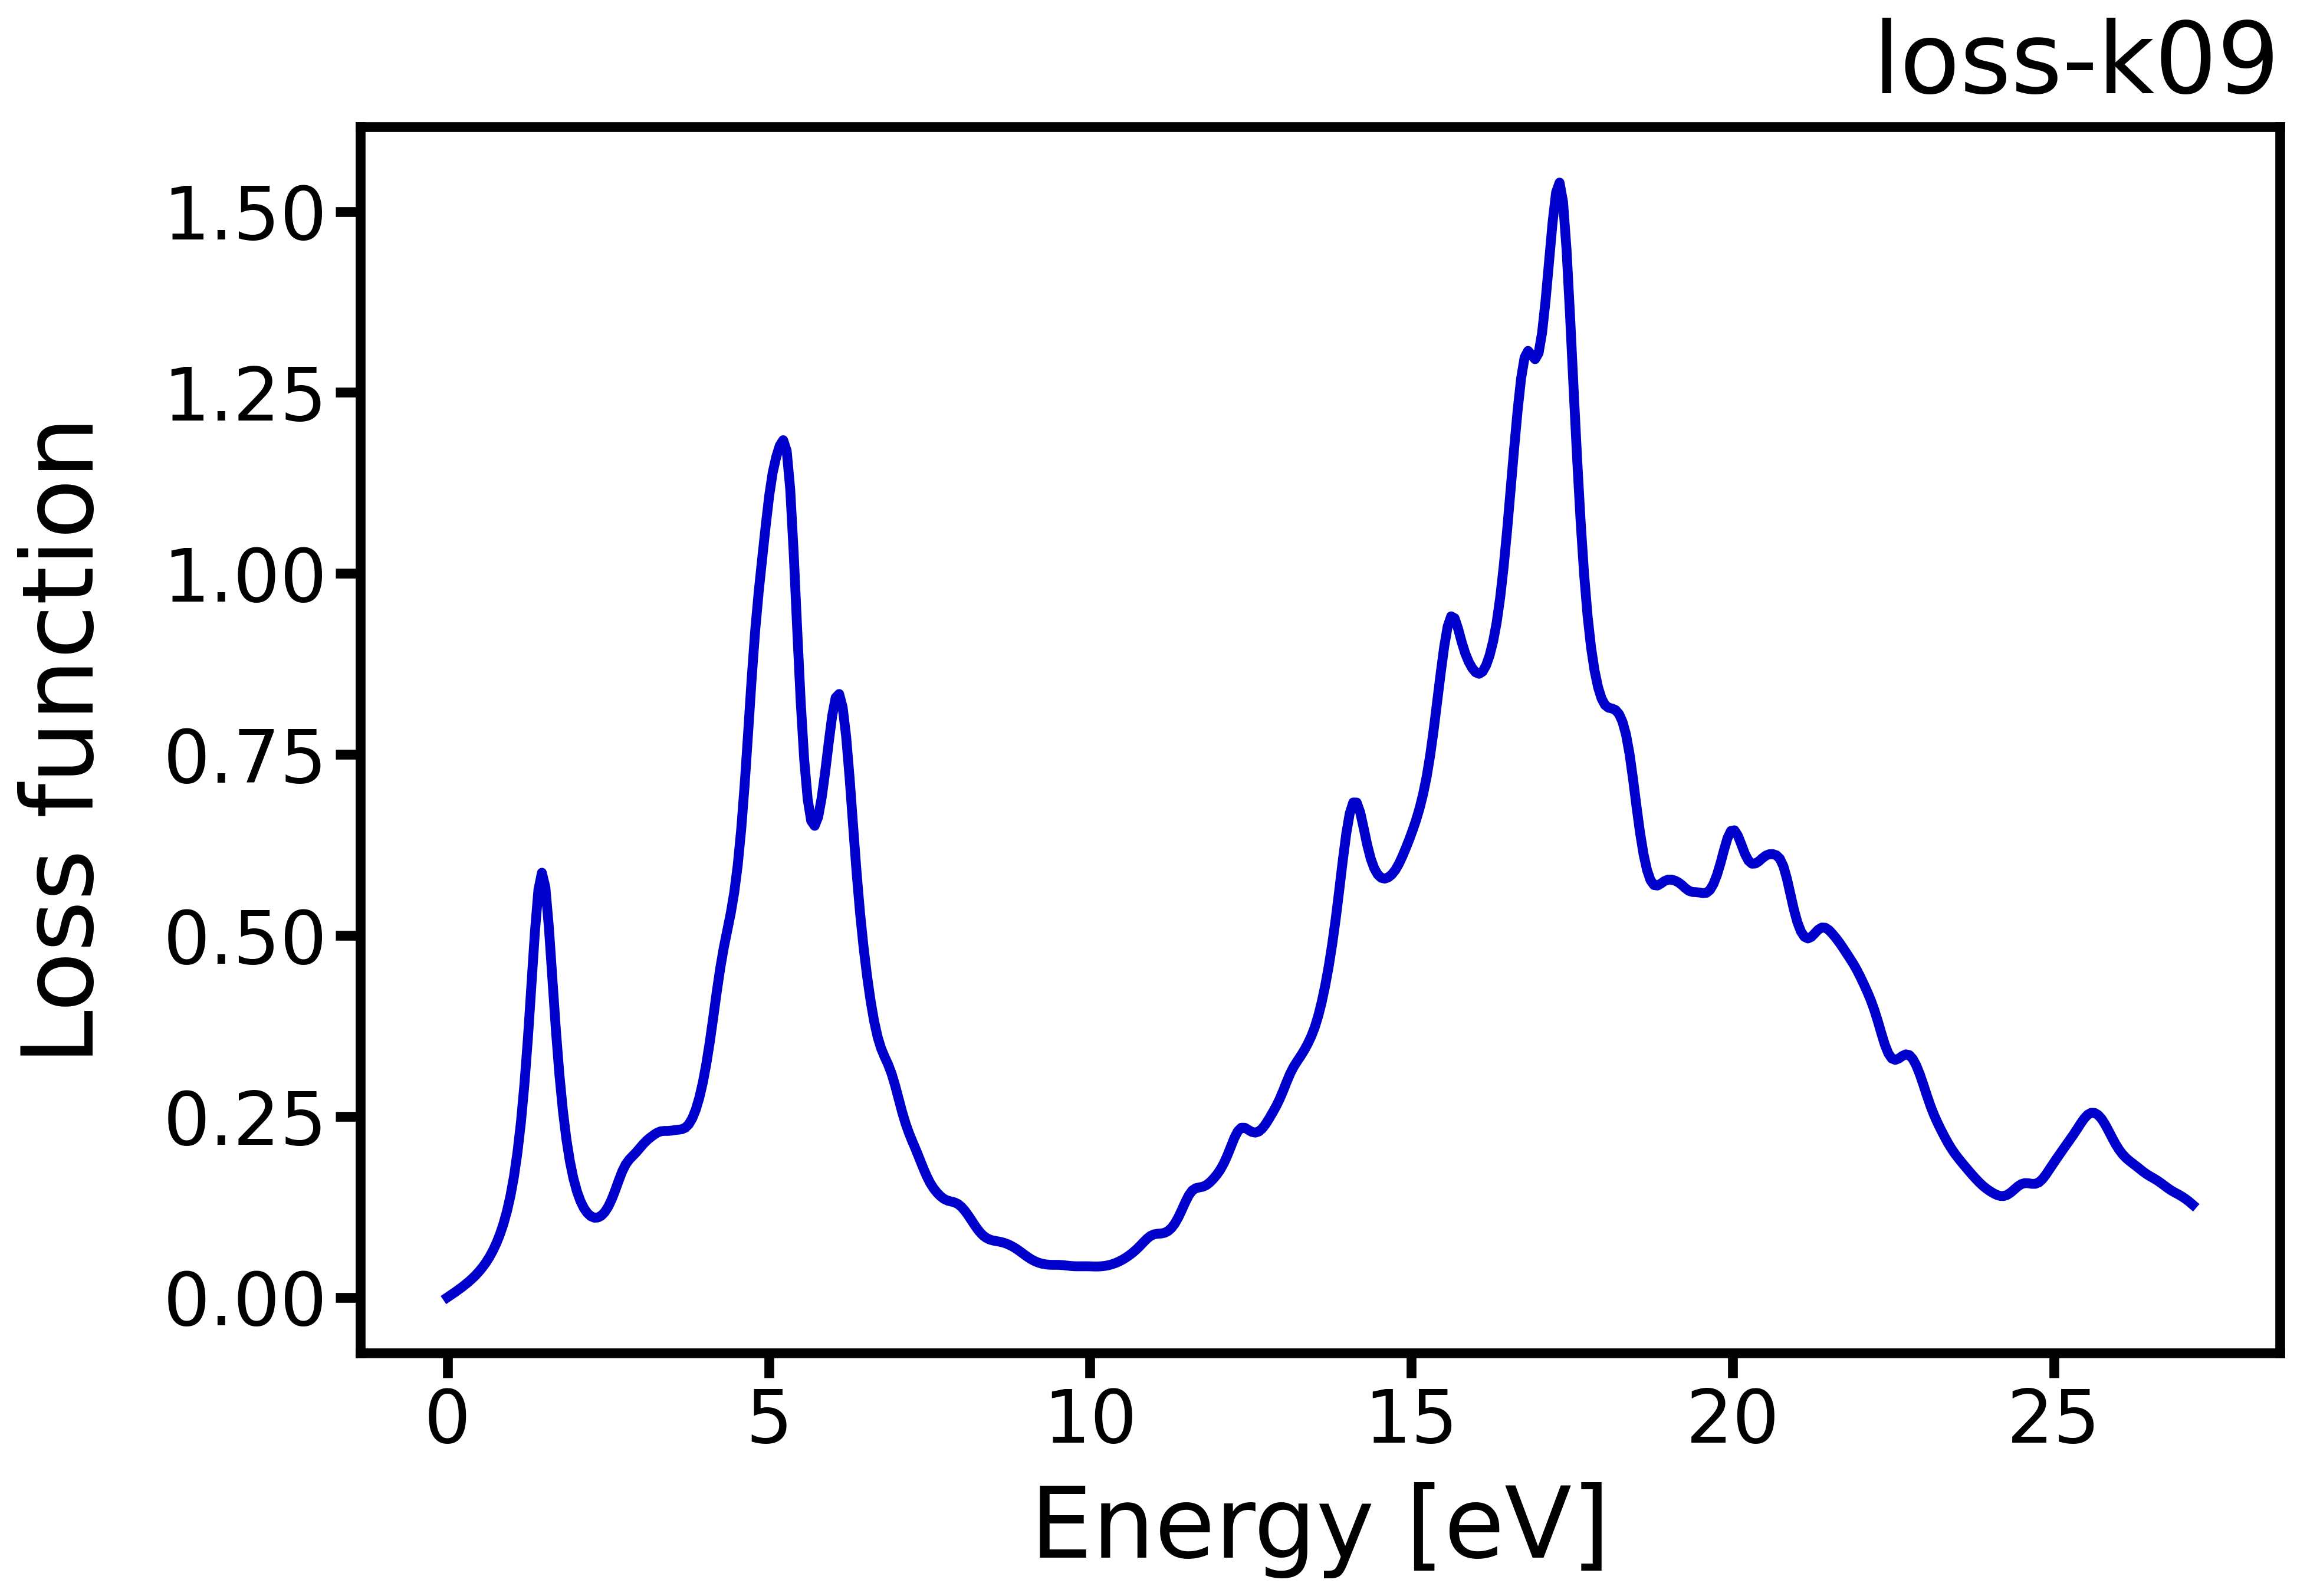
</figure>

<a id='6-1'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>6.1 Converging the loss spectrum w.r.t. the mesh in reciprocal space</b>

The results shown above are obtainedd using <code><span style="color:mediumblue">ngridk</span></code> = <b>"9 9 1"</b> for <span style="color:red;font-weight:bold">both</span> the ground-state (<code><span style="color:green">groundstate</span></code>) and excited-states (<code><span style="color:green">xs</span></code>) calculations. The loss spectrum is not fully converged at this mesh. Further calculations should be performed with finer meshes until the desired convergence is reached.

In order to do so, repeat the calculations above for

```
"18 18 1"  -->  rpa-k18  -->  loss-k18
"27 27 1"  -->  rpa-k27  -->  loss-k27
"36 36 1"  -->  rpa-k36  -->  loss-k36
"45 45 1"  -->  rpa-k45  -->  loss-k45
 ...
``` 
 
Notice that at each step the complexity of the calculation is increased in a non linear way, resulting soon in quite large execution times.

<hr style="border:1px solid #DDD"> </hr>

<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Hint: Plotting several spectra</span></strong> 
    
</summary>  

Assuming you have already calculated the loss function using different <b>k</b>-meshes, before plotting the results you can prepare the files to be plotted in the following way.

For each <b>k</b>-mesh execute the commands:
    
```
export KGRID="k09" 
cp rpa-$KGRID/LOSS_FXCRPA_OC11_QMT001.OUT loss-$KGRID
```
    
If you want to change the <b>k</b>-mesh, you only need to change accordingly the first command and cut and paste the second line on the screen.

</details>

<hr style="border:1px solid #DDD"> </hr>
<span style="color:firebrick;font-weight:bold">Hint</span>: You can now compare two or more loss spectra by using the script <code><b>plot.files.py</b></code> similarly to what follows

<hr style="border:1px solid #DDD"> </hr>

<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ Comparison of results for different grids in reciprocal space</span></strong> 
    
</summary>  
<figure>
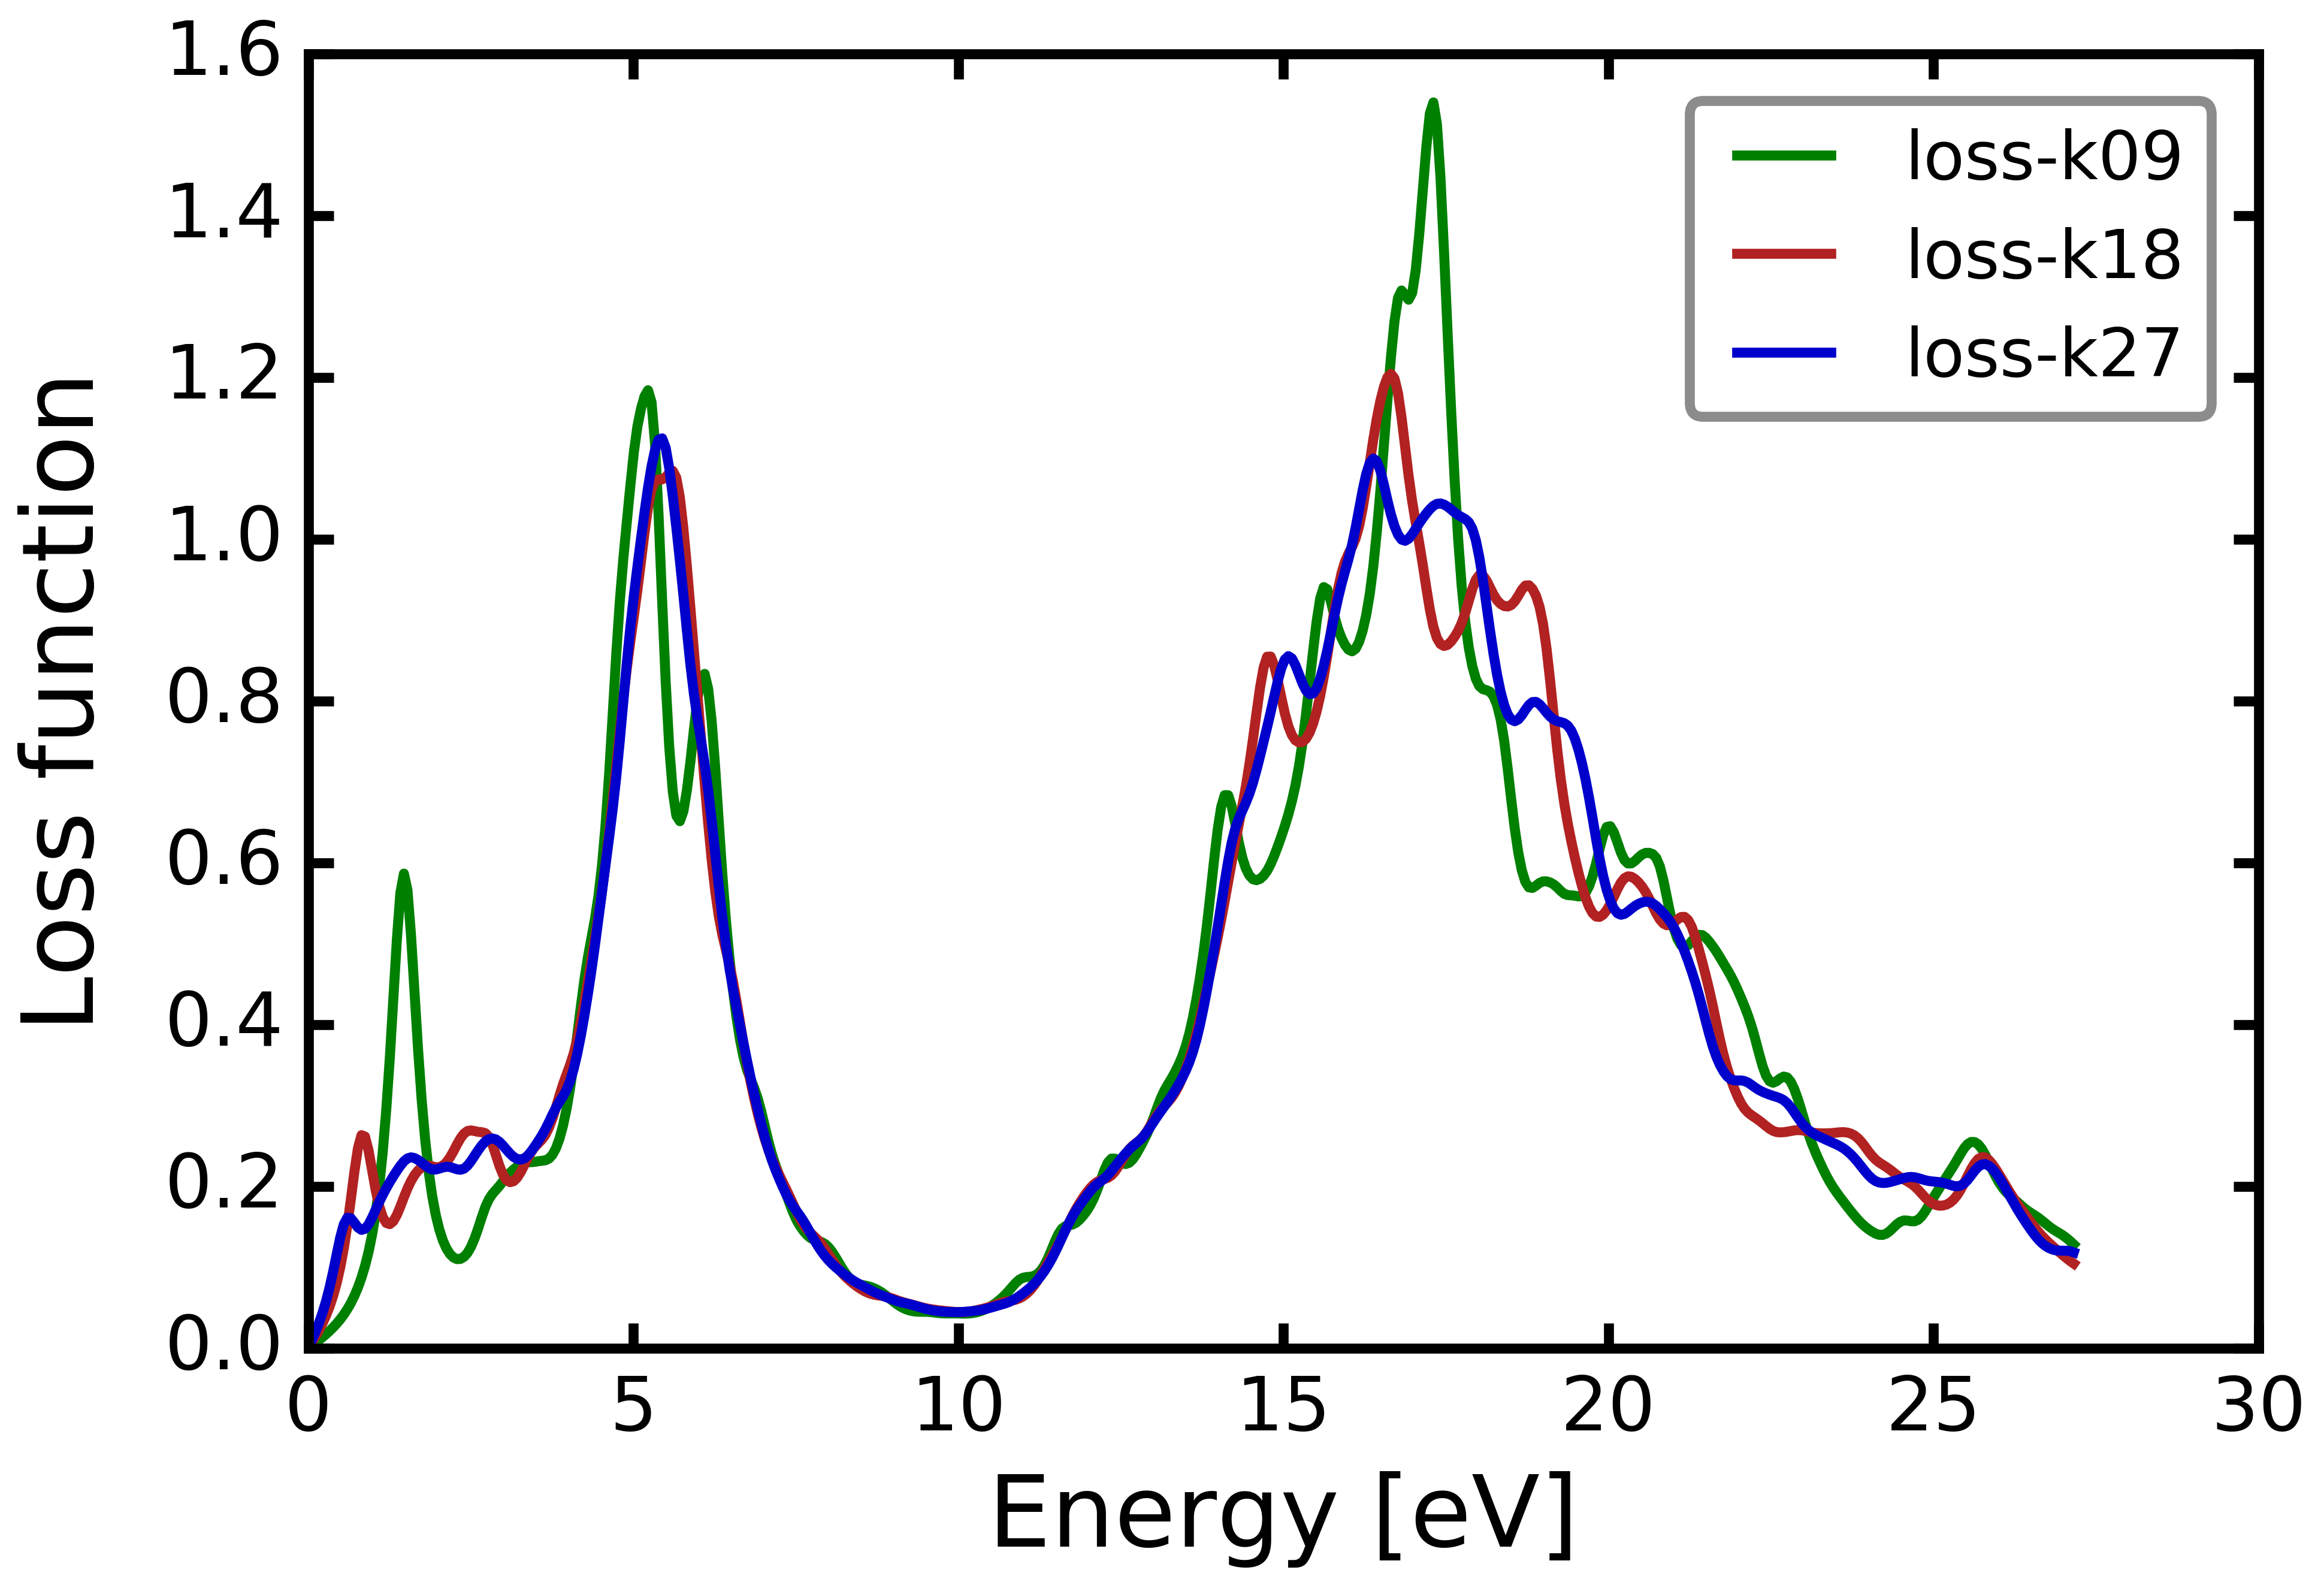
</figure>
</details>

<hr style="border:1px solid #DDD"> </hr>

<details>
<summary><strong><span style="color:firebrick">$\Rightarrow$ (Over)-converged w.r.t. k-mesh loss spectrum of graphene</span></strong> 
    
</summary>  
<figure>
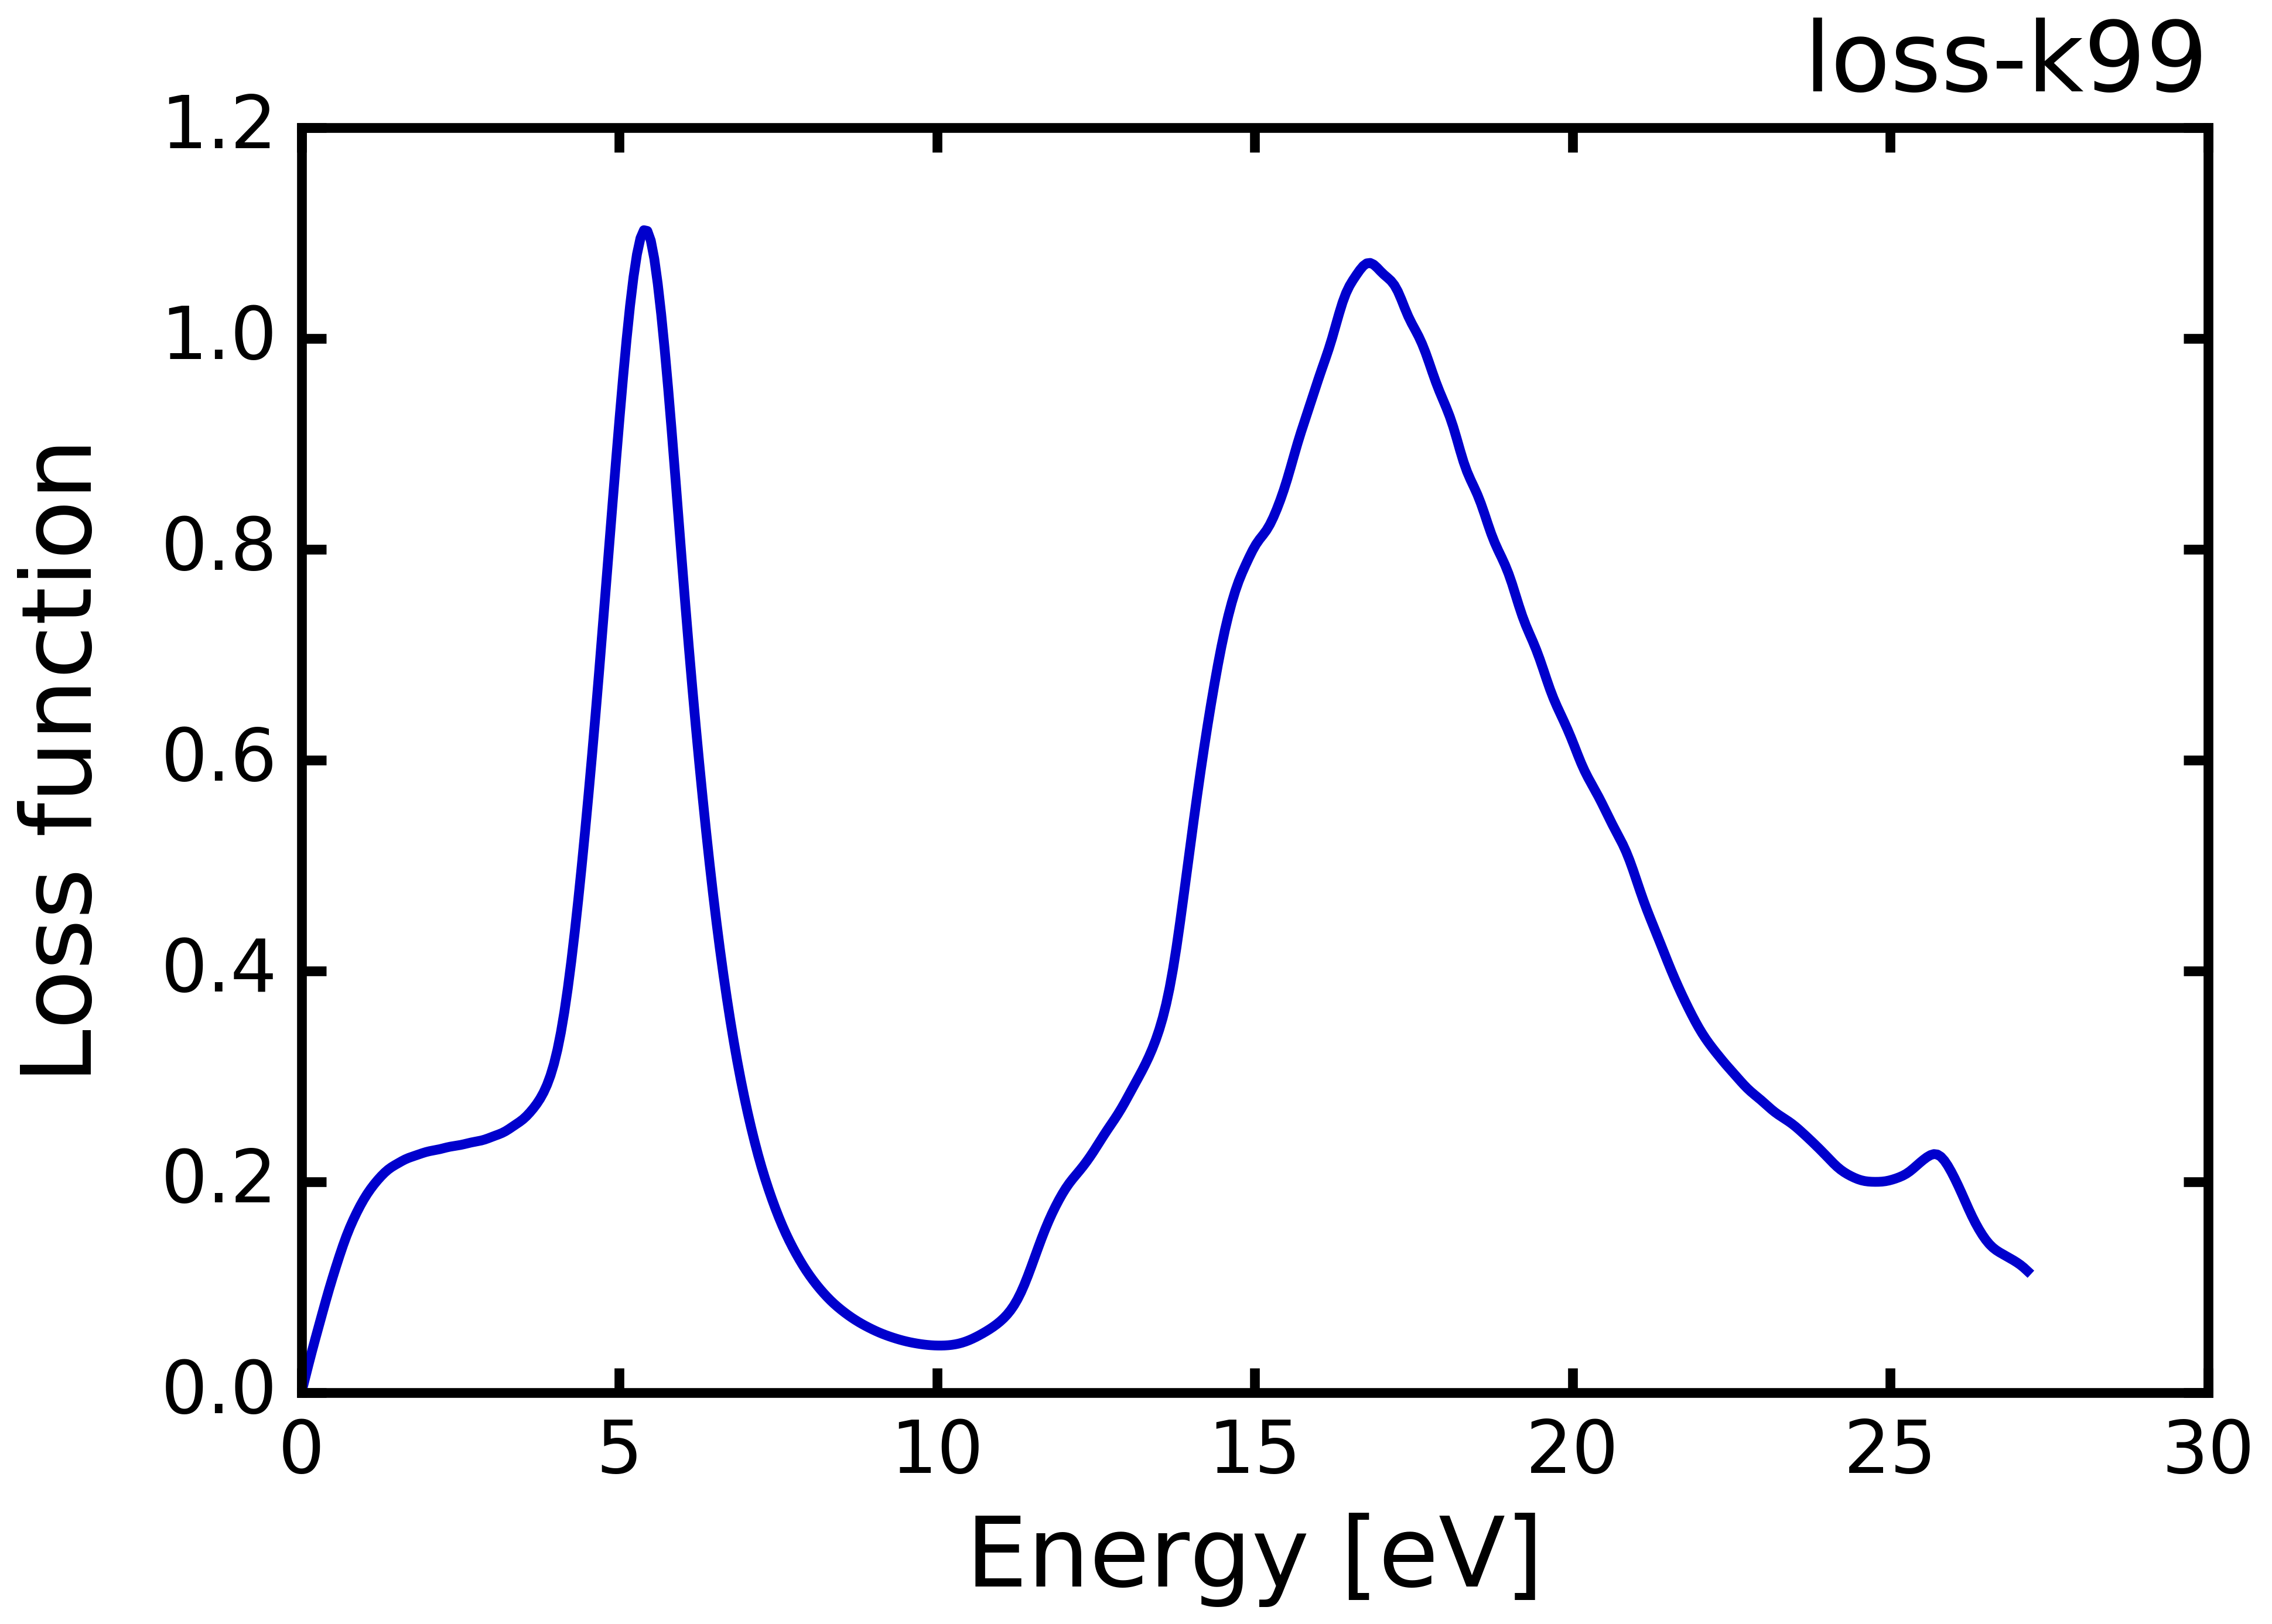
</figure>
</details>

<hr style="border:1px solid #DDD"> </hr>

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Questions</b></span>

* At which value of <code><span style="color:mediumblue">ngridk</span></code> can you consider the loss spectrum as converged?
* Consider separately the features in the loss spectrum below and above 10 eV. Do they converge at the same value of <code><span style="color:mediumblue">ngridk</span></code>?
</div>

<a id='6-2'></a>
<hr style="border:1px solid #DDD"> </hr>

<b>6.2 Converging the loss spectrum w.r.t. the number of basis functions</b>

Another very important parameter for the convergence of the loss spectrum is the attribute <code><span style="color:mediumblue">rgkmax</span></code> of the element <code><span style="color:green">groundstate</span></code>. This parameter, together with the total number of local orbitals, is related to the number of basis functions used for the expansion of the Kohn-Sham wave-functions.

The loss spectrum is not fully converged for <code><span style="color:mediumblue">rgkmax</span></code> = <b>"4.0"</b>, which is the value we used above. Further calculations should be performed with larger values (e.g., <b>"4.5"</b>, <b>"5.0"</b>, <b>"5.5"</b>, etc.) until the desired convergence is reached.

<div style="border: 2px solid black; padding: 10px; margin: 10px;">
<span style="color:green"><b>Questions</b></span>

* How can you further improve the precision of your calculations?
* Which further parameters are relevant to be optimized?
</div>

<hr style="border:1px solid #DDD"> </hr>